<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 3.2: Calibration with Neural Networks </strong></p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>


# Obectives

- Implement a calibration procedure using a (pre-trained) NN-Surrogate pricer
- Test the calibration performances on simulated data (controlled environment)
- Test the calibration performances on real data

We focus on a **European call** in the **Black–Scholes** model, so that we can easily generate option prices with **Monte Carlo** (slow but flexible) and check accuracy against the **closed-form Black–Scholes formula**

**Inputs** (features): $x = (\sigma, r, S_0, K, T)$

**Output** (target): option price $y=F(x)$.

> You will:  
> **(1)** load a pre-trained NN surrogate (or train one quickly if missing),
> 
> **(2)** build a calibration loss function (MSE vs “market” prices),
> 
> **(3)** calibrate a *single* volatility parameter \(\sigma\) (1D),
> 
> **(4)** compare **BS exact calibration** vs **NN-based calibration**: accuracy & speed,
> 
> **(5)** Estimate the implied volatility on real data.


** NOTA:** This Tutorial continues **DLF_3_1_FastPricing_BS_Surrogate.ipynb**: we now use the trained neural-network surrogate as a *pricing engine* inside a **calibration loop**.

## 0. Setup... and retrieve functions previously defined in Tutorial 3.1

In [1]:
# --- Imports & global settings ---
import os, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import norm
from scipy.optimize import minimize
from time import perf_counter
import datetime
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
# Training with early stopping on validation RMSE
os.makedirs("Data", exist_ok=True)
file_save_best_model = "Data/best_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED=0
np.random.seed(SEED)
torch.manual_seed(SEED)

def Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity):
    r"""
    Black_Scholes_Formula(vol, risk_free_rate, current_price, strike, maturity)
    Function computing the Black-Scholes formula to obtain the price of a Call option
    
    Inputs
    ----------
    vol            : volatility of the underlying
    risk_free_rate : value of the risk free rate
    current_price  : current value of the underlying price (X_t)
    strike         : value of the strike (K)
    maturity       : Maturity of the option (T-t)

    Output
    -------
    Value          : Call option price from BS formula : X0 \Phi(d_1) - K e^{-r(T_t)} \Phi(d_2)
    """
    # Computation of d_1 and d_2 of the Black-Scholes Formula
    d_1 = (np.log(current_price/strike) + (risk_free_rate + 0.5 * vol**2)*maturity)/(vol * np.sqrt(maturity))
    d_2 = d_1 - vol * np.sqrt(maturity)
    # Black-Scholes formula
    Value = current_price * norm.cdf(d_1) - strike * np.exp(- risk_free_rate * maturity) * norm.cdf(d_2)
    return Value


def mc_call_price(sigma, r, S0, K, Tmt, n_simulations=20000):
    """
    Computes the Call option prices from Monte Carlo simulations
    sigma, r, S0, K, Tmt: parameters of the Call option
    n_simulations: number of simulations in the Monte Carlo approximation
    """
    Z = np.random.randn(n_simulations, 1)
    
    drift = (r - 0.5 * sigma**2) * Tmt
    diff  = sigma * np.sqrt(Tmt)

    S_T = S0 * np.exp(drift + diff * Z)          # (n_sim, n_options) ou (n_sim,1)
    CF  = np.maximum(S_T - K, 0.0)
    return np.exp(-r * Tmt) * np.mean(CF, axis=0)
    

sigma_true = 0.2
r = 0.01
S0 = 100.0
K = np.array([80, 90, 100, 110, 120.0])
T = np.array([0.25, 0.5, 1.0, 1.0, 1.0])

bs = Black_Scholes_Formula(sigma_true, r, S0, K, T)
mc = mc_call_price(sigma_true, r, S0, K, T, n_simulations=200000)

print("BS :", bs)
print("MC :", mc)
print("abs err:", np.abs(mc - bs))

BS : [20.23684363 12.11158143  8.43331869  4.61011457  2.3406494 ]
MC : [20.2683541  12.13758166  8.44706831  4.6106303   2.3380464 ]
abs err: [0.03151047 0.02600023 0.01374962 0.00051573 0.002603  ]


## 1. Generation of market Prices

In this section, we want to generate call option prices for different strikes and maturity, from de the Black-Scholes model and a fixed (true) volatility $\sigma_\text{true}$. This simulated dataset represents observed call prices, from which we want to estimate the implied volatility, i.e. retrieve $\sigma_\text{true}$. 

### Reminder

For a European call:
\begin{equation}
C = S_0 N(d_1) - K e^{-rT}N(d_2),
\end{equation}
with
\begin{equation}
d_1=\frac{\ln(S_0/K)+(r+\tfrac12\sigma^2)T}{\sigma\sqrt{T}},
\quad
d_2=d_1-\sigma\sqrt{T}.
\end{equation}

** Remark **: The normal cumulative distribution function $N$ can be computed with 'norm.cdf' function in Scipy

<span style="color: blue;">**1.1** Generate Call option prices $\{C^{mkt}_i, i=1, \dots, I \}$ with the function `bs_call_price` and the following parameters:</span>
- <span style="color: blue;">$\sigma_\text{true}=0.2$ </span>
- <span style="color: blue;">$r=0.01$</span>
- <span style="color: blue;">$S_0=300$</span>
- <span style="color: blue;"> $K \in \{50, 100, \dots, 500 \}$ </span>
- <span style="color: blue;"> $T \in \{ 0.5, 1, 1.5\}$ </span>

Check result: $T=0.5$, $K=50 \longrightarrow$ $C = 250.2493760403659$

<span style="color: blue;">**1.2** Plot the markets prices with respect to $K$, for fixed maturity $T=1$, and with respect to maturity for fixed strike $K=300$.</span> 

Number of options: 30
Example (K,T,C): 50 0.5 250.2493760403659


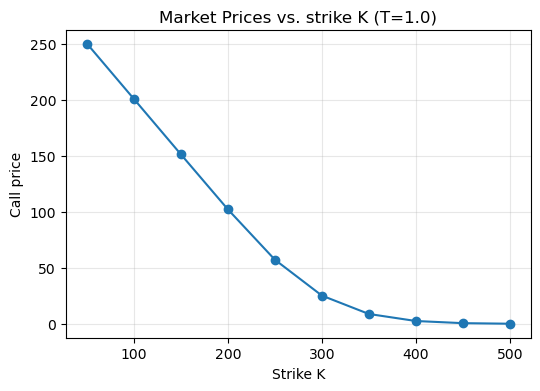

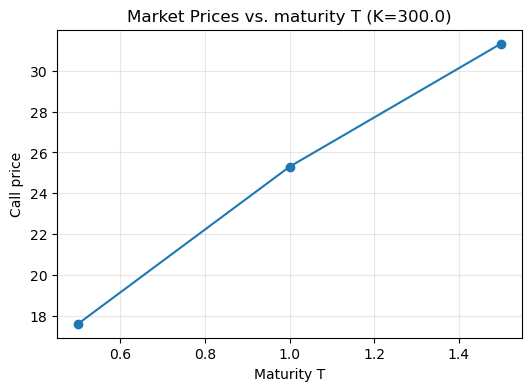

In [3]:
# YOUR CODE HERE

print('Number of options:', C_mkt.size)
print('Example (K,T,C):', K_mkt[0], T_mkt[0], C_mkt[0])


# PLOT C_mkt as function of K_mkt, for T_mkt = 1
# YOUR CODE HERE


# PLOT C_mkt as function of T_mkt, for K_mkt = 300
# YOUR CODE HERE



## 2. Calibration with a NN fast pricer

Now that we have generrated market prices, the objective is to calibrate the Black-Scholes model by using the NN fast pricer previously built in Tutorial 3.1. 

The first step is then to load the pre-trained NN fast pricer, without forgetting the scaling parameters.

In [4]:
# First step: redifne the MLP Class in order to characterize the state dimension of the NN. 
# Note that we could have learnt it from the saved NN. We rebuilt the MLP Class for simplicity
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self, x):
        return self.net(x)
model = MLP(in_dim=5).to(device)

# Load the previously trained model (from Tutorial 3.1)
file_save_best_model = "fast_pricing_mlp.pt"
state = torch.load(file_save_best_model, map_location='cpu')
model.load_state_dict(state)
model.eval()

# Also import the scaling parameters
scaler_X = joblib.load("scaler_X.joblib")
scaler_y = joblib.load("scaler_y.joblib")

### 2.1 Cost function

The objective is to calibrate the Black-Scholes model, i.e. to estimated the implied volatility $\sigma_\text{imp}$.

We propose to estimate $\sigma_\text{imp}$ by minimizing the quadrati error:
\begin{equation}
\sigma_\text{imp} = \arg\min_{\sigma>0} J^{method}(\sigma) 
\end{equation}
with 
\begin{equation}
J^{method}(\sigma)  = \frac{1}{I}\sum_{i=1}^I \| C^{mkt}_i - C^{method}_i(\sigma) \|^2
\end{equation}
where $C^{method}_i(\sigma)$ is the price obtained from the NN pricer if $method=NN$ of from the Monte Carlo pricer if $method=MC$, with volatility $\sigma$ and input $X_i$. 


<span style="color: blue;">**2.1** Build the function `nn_price_call` that computes the price from the NN Surrogate Fast pricer.</span>

<span style="color: blue;">**2.2** Build the function `loss_nn` that computes the quadratic loss $J^{NN}(\sigma)$ and evaluate it at $\sigma=\sigma_\text{true}$.</span>

Expected result: `loss_nn(sigma_true)= 0.6787426081780114`

In [5]:
# Useful function 
def build_features(sigma, r, S0, K, T):
    '''
    creates the right form of NN input from the pricer parameters  sigma, r, S0, K, T
    '''
    sigma = np.asarray(sigma, dtype=float)
    r  = np.asarray(r, dtype=float)
    S0 = np.asarray(S0, dtype=float)
    K  = np.asarray(K, dtype=float)
    T  = np.asarray(T, dtype=float)
    return np.stack([sigma, r, S0, K, T], axis=1)

def nn_price_call(model, scaler_X, scaler_y, X):
    '''
    compute y = F(x) the price of the call option with characteristics X by using the NN Fast pricer
    Inputs
    ------
    X: numpy array (N, d_in) in raw feature space.

    Output
    ------
    y: numpy array (N, 1) of prices.
    '''
    # YOUR CODE HERE


def loss_nn(sigma):
    # YOUR CODE HERE


print('loss_nn(sigma_true)=', loss_nn([sigma_true]))

loss_nn(sigma_true)= 0.6787426081780114


### 2.2 Minimization


The last part of the calibration procedure consists in implementing the minimization of $J(\sigma)$. 


For this, we propose to use the scipy function `minimize` with the following characteristics:
`minimize(loss_nn,x0=np.array([sigma_0]), method="Nelder-Mead", bounds=[SIGMA_BOUNDS],options={"maxiter": 300})`

- criterion to minimize: $J^{NN}$ = `loss_nn` function
- `x0`: initial value of input, here $\sigma_0 = 0.1$
- `method`: optimization method to be used $\rightarrow$ Nelder-Mead (simplex method, useful here because it does not need the gradient)
- `SIGMA_BOUNDS = (0.05, 0.6)`: constraints on the values of $\sigma \in [0.05 ; 0.6]$ (corresponding to $\mathcal{D}_\text{domain}$)
- `maxiter`: maximum number of minimization iteraions $\rightarrow$ 500
- `xatol:`: size tolerance of the simplex $\rightarrow$ 1e$^{-8}$
- `fatol`: tolerance in the difference between two successive function evaluations $\rightarrow$ 1e$^{-12}$

<span style="color: blue;">**2.3** Implement the minimization procedure to get the estimated implied volatility.</span>

<span style="color: blue;">**2.4** Compute the resulting prices with the estimated implied volatility and compare to the true prices in a graph.</span> 

<span style="color: blue;">**2.5** Add to simulated call prices a random noise from $\mathcal{N}(0~;~\eta^2)$, with $\eta=0.1$.</span> 

True sigma: 0.2
NN calib: sigma_hat=0.200391 | iters=14 | evals=28 | time=0.0228s


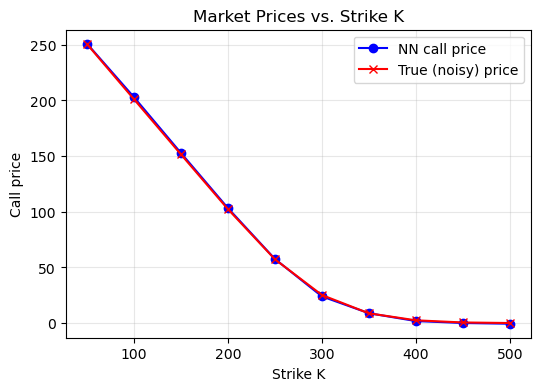

In [6]:
# YOUR CODE HERE
sigma_0 = 
SIGMA_BOUNDS = 

t0 = perf_counter()

# Minimize (loss, x0, method, bouds, options)


t1 = perf_counter()


# Computation of prices with the estimated volatility


# Plot Results




### Comparison with MC pricer

The objective of this part is to implement the implied volatility estimation with the Monte Carlo pricer and to compare the result and the computation time with the use of the NN pricer

<span style="color: blue;">**2.4** Compute the function `loss_mc` that computes the loss $J^{MC}(\sigma)$.</span>

<span style="color: blue;">**2.5** Implement the minimization of $J^{MC}(\sigma)$ and commpare the results with the NN Fast pricer.</span>

loss_mc(sigma_true)= 0.0006052417262925639
loss_mc(sigma_hat_mc)= 0.00694433647012283
True sigma: 0.2
MC calib: sigma_hat=0.198750 | iters=300 | evals=810 | time=15.1252s
Speed-up NN vs. MC: 662.501741x


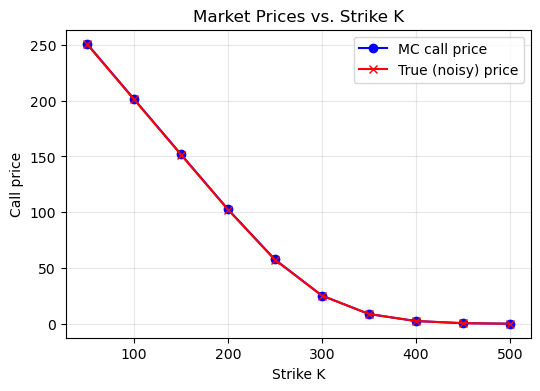

In [7]:
def loss_mc(sigma):
    # YOUR CODE HERE

print('loss_mc(sigma_true)=', loss_mc([sigma_true]))



t2 = perf_counter()

# Minimize (loss, x0, method, bouds, options)


t3 = perf_counter()

print(f'Speed-up NN vs. MC: {(t3-t2)/(t1-t0):4f}x')

# Computation of prices with the estimated volatility


# Plot Results



## 3. Calibration on real data

The objective of this part is to estimate the (smile of) implied volatility from real data of call prices.

### Implied volatility

In pratcie, the implied volatility does not correspond to the volatility estimatd on all the observed call option prices, but it is estimted independently for each call option price. ** One implied volatility per call option **. 

We first download the data of call option prices on Apple Stock, correponding to the following characteristics:

- $S_0$ = 274.73\$
- $t_0$ = 2025/12/26
- $T$ = 2026/12/18
- $r$=0.01*

(*) the risk-free rate value is only an assumption here

## 3.1 Data downloading and preparation

**First step** Download the data

In [8]:
file_data =  "Data/AAPL_Call.csv"
# ---------- Chargement & préparation ----------
df = pd.read_csv(file_data, sep = ';')
df.head()

,Contract Name,Strike,Last Price,Bid,Ask,Change,Volume,Open Interest
0,AAPL261218C00005000,5,264.64,267.50,271.30,0.0,1.0,2
1,AAPL261218C00010000,10,245.23,251.00,254.85,0.0,10.0,15
2,AAPL261218C00015000,15,186.06,238.95,242.35,0.0,4.0,5
3,AAPL261218C00020000,20,240.80,255.65,259.55,0.0,1.0,5
4,AAPL261218C00025000,25,184.65,229.35,232.75,0.0,1.0,2


<span style="color: blue;">**3.1** Set $S_0$ and $r$ to their observed values, and build the "market prices" as the mid price, i.e. the price in the middle between bid and ask.</span>

<span style="color: blue;">**3.2** Build vectors `K_vec`, `C_mkt_vec` and `T_vec` regrouping all the call option prices and their corresponding strike and maturity.</span>

In [10]:
# YOUR CODE HERE
S0 = 
r = 
# Price = mid (bid/ask) 
C_mkt_series = 

# Build K_vec, C_mkt_vec, T_vec (as numpy)

print(K_vec, T_vec)

[  5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  60.  70.  80.  85.
  90.  95. 100. 105. 110. 115. 120. 125. 130. 135. 140. 145. 150. 155.
 160. 165. 170. 175. 180. 185. 190. 195. 200. 205. 210. 215. 220. 225.
 230. 235. 240. 245. 250. 255. 260. 265. 270. 275. 280. 285. 290. 295.
 300. 305. 310. 315. 320. 325. 330. 335. 340. 345. 350. 360. 370. 380.
 390. 400. 410. 420. 430. 440. 450. 460. 470. 480. 490. 500. 510. 520.
 530.] [0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219 0.97808219
 0.97808219 0.97808219 0.978082

## 3.2 Numerical calibration

<span style="color: blue;">**3.3** Estimate the implied volatility independently for each option price, by using the surrogate pricing model.</span>

<span style="color: blue;">**3.4** For each option price, compare the real price and the price from the surrogate model using the estimated implied volatility. One can plot the results in a graph comparing real data and reconstructed prices.</span>

<span style="color: blue;">**3.5** Plot the implied volatility with respect to $K$. Do you see the smile ?</span>



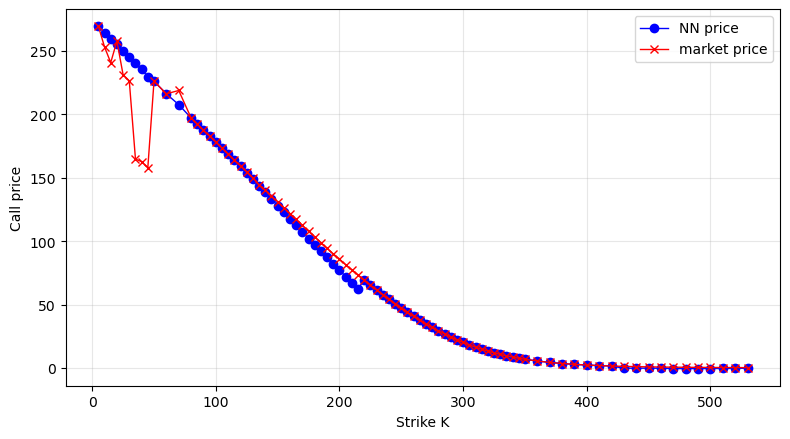

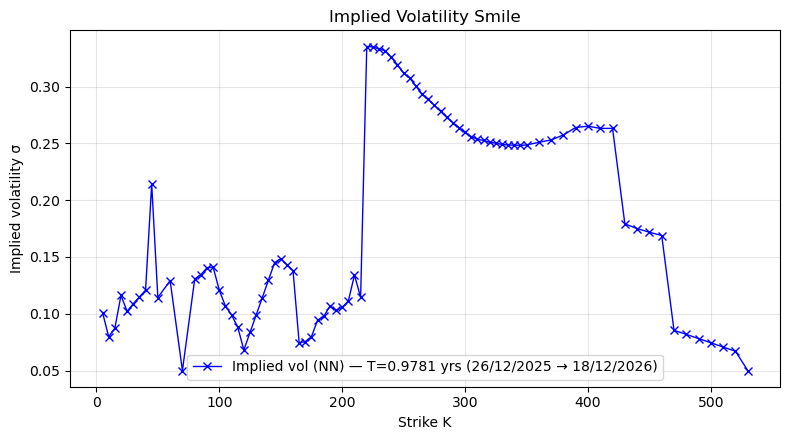

In [11]:
# ==============================
# Calibration 
# ==============================

# YOUR CODE HERE : compute the vector 
# - imp_vol_nn : implied volatility
# - C_nn : resulting call prices






## 3.3 Comparison with classical implied volatility estimation

In the following, we estimate the implied volatiity with the classical Newton algorithm and we compare with the results obtained with the surrogate model.

[       nan        nan        nan 1.7407763         nan        nan
        nan        nan        nan 0.85621685 0.7664115  1.3779029
 0.71206987 0.693506   0.6714235  0.6500662  0.63848066 0.6313404
 0.6153493  0.59595484 0.5844682  0.56460184 0.5508716  0.51653063
 0.52140373 0.50593626 0.49059102 0.47943568 0.46729764 0.45553717
 0.43956143 0.42430386 0.41582307 0.4057811  0.39258417 0.38360953
 0.37897617 0.36680472 0.3620826  0.35430238 0.34881267 0.3417972
 0.33431584 0.32811785 0.32217672 0.31642267 0.30923307 0.30574918
 0.2992255  0.2929734  0.28930128 0.28548205 0.28080693 0.27688763
 0.27323675 0.27007723 0.26671565 0.26314896 0.26033804 0.25834402
 0.25573534 0.2532757  0.25156096 0.2504421  0.2491662  0.24746181
 0.24695353 0.24555178 0.24425864 0.24424085 0.24439429 0.24507216
 0.24588257 0.24698478 0.24832332 0.24987222 0.25193626 0.2537687
 0.25561425 0.25780898 0.26078883 0.26239228 0.2648321  0.26751363
 0.26941928]


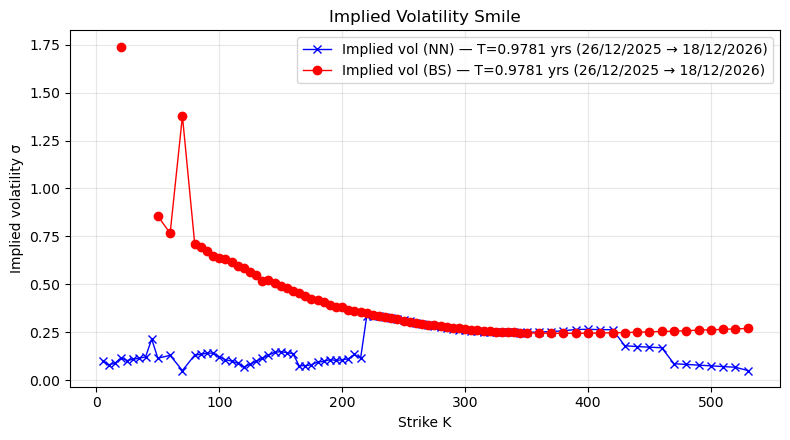

In [13]:
def bs_vega(sigma, r, S0, K, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S0 * norm.pdf(d1) * np.sqrt(T)



def implied_vol_call(C_obs, S, K, Tmt, r, tol=1e-8, max_iter=100, sigma_max=5.0, damping=0.7):
    """  
    Compute Black–Scholes implied volatility by Newton's method following the algorithm in your slide.

    Initialization: sigma0 = sqrt( 2*log( S / (K*exp(-r*(T-t))) ) / (T-t) )

    Inputs
    ----------
    C_obs     : Observed call price (assumed arbitrage-free).
    S         : Spot price S_t.
    K         : Strike.
    Tmt       : Maturity date.
    r         : Risk-free rate.
    tol       : |C_bs - C_obs| stopping tolerance.
    max_iter  : Maximum Newton iterations.
    sigma_max : Upper bound for volatility to avoid divergence.
    damping   : Damping factor in (0,1] for the Newton step; 1.0 = pure Newton,
        <1.0 helps stability when Vega is small or non-linearities are strong.

    Outputs
    -------
    sigma : Estimated Implied volatility.
    n_iter : Number of Newton iterations performed.
    """
    #tau = max(T - t, 1e-12)

    # Arbitrage bounds for a call under BS (used to check/clip price)
    Bound_Inf = max(S - K * np.exp(-r * Tmt), 0.0)
    Bound_Sup = S
    # Arbitrage Check
    
 
    # Outside bounds → no implied vol
    if not (Bound_Inf <= C_obs <= Bound_Sup):
        return None, 0

    # Jackel (robust) initialization
    sigma = np.sqrt(2*np.abs(np.log(S/K))/Tmt)   # simple safe guess

    for n in range(1, max_iter + 1):
        C = Black_Scholes_Formula(sigma, r, S, K, Tmt)
        diff = C - C_obs
        
        if abs(diff) < tol:
            return sigma, n

        vega = bs_vega(sigma, r, S, K, Tmt)

        if vega < 1e-10:
            # fallback
            sigma *= 0.5
            continue
        
        # Newton step with damping
        step = diff / vega
        sigma_new = sigma - damping * step

        # enforce domain of sigma
        if sigma_new <= 0 or not np.isfinite(sigma_new):
            sigma *= 0.5
        else:
            sigma = min(sigma_new, sigma_max)

    # no convergence
    return sigma, max_iter




imp_vol = np.empty_like(C_mkt_vec, dtype=np.float32)
for i in range(C_mkt_vec.shape[0]):
    sigma, max_iter = implied_vol_call(C_mkt_vec[i], S0, K_vec[i], T_vec[i], r)
    imp_vol[i] = sigma

print(imp_vol)

plt.figure(figsize=(8, 4.5))
plt.plot(K_vec, imp_vol_nn, 'x-',color='b', lw=1,
         label=f'Implied vol (NN) — T={(Tmt):.4f} yrs '
               f'({d.strftime("%d/%m/%Y")} → {D.strftime("%d/%m/%Y")})')
plt.plot(K_vec, imp_vol, 'o-', color='r', lw=1,
         label=f'Implied vol (BS) — T={(Tmt):.4f} yrs '
               f'({d.strftime("%d/%m/%Y")} → {D.strftime("%d/%m/%Y")})')

plt.xlabel('Strike K')
plt.ylabel('Implied volatility σ')
plt.title('Implied Volatility Smile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
